In [9]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

import required libraries

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [11]:
df=pd.read_csv("C:\Tekworks\Day 17\knn_regression_dataset.csv")
df.head()

,age,income,loan_amount,credit_score,city,employment_type,target
0,56,25903.305196,286348.192562,789.476075,Chennai,Salaried,158793.631698
1,69,53051.954538,180018.190719,596.334039,Chennai,Salaried,115596.093965
2,46,38654.738821,211234.236288,611.531000,Chennai,Salaried,127231.057638
3,32,28666.194356,246629.541594,710.171152,Chennai,Unemployed,145102.187078
4,60,40301.406736,129081.713353,622.900855,Hyderabad,Unemployed,110623.128404


In [12]:
df.dtypes

age                  int64
income             float64
loan_amount        float64
credit_score       float64
city                object
employment_type     object
target             float64
dtype: object

In [13]:
# checking for null values
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              1000 non-null   int64  
 1   income           970 non-null    float64
 2   loan_amount      970 non-null    float64
 3   credit_score     971 non-null    float64
 4   city             1000 non-null   object 
 5   employment_type  1000 non-null   object 
 6   target           1000 non-null   float64
dtypes: float64(4), int64(1), object(2)
memory usage: 54.8+ KB


In [15]:
df.describe()

,age,income,loan_amount,credit_score,target
count,1000.00000,970.000000,970.000000,971.000000,1000.000000
mean,43.81900,52924.860515,204508.531872,649.422223,125258.332699
std,14.99103,21236.060048,58239.083910,71.104784,31423.294558
min,18.00000,6556.169327,49024.392209,440.620482,40800.918241
25%,31.00000,40854.271568,168890.053957,600.334270,105707.679044
50%,44.00000,51119.925190,200190.693629,649.978043,123651.542971
75%,56.00000,61104.364633,235458.241233,696.092859,141801.468844
max,69.00000,220985.397589,597644.058452,858.968130,333440.450713


In [16]:
df.isnull().sum()

age                 0
income             30
loan_amount        30
credit_score       29
city                0
employment_type     0
target              0
dtype: int64

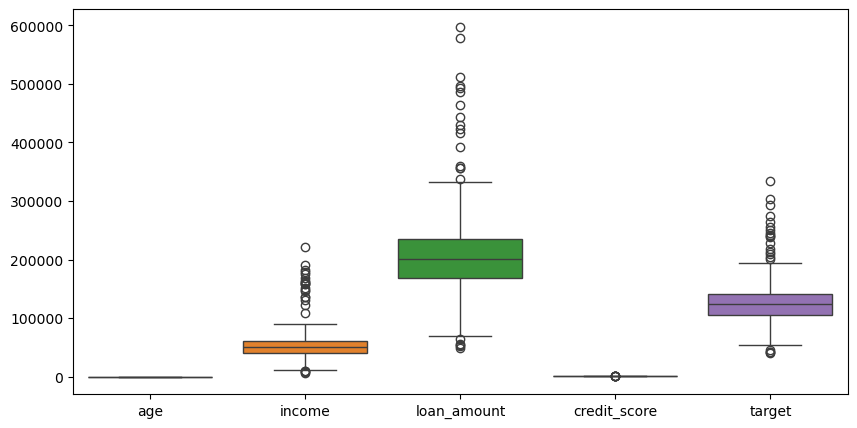

In [17]:
# box plot to check for outliers
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

In [18]:
#handled missing values by filling them with median values
# find the median values of the credit score and income columns and loan amount column
median_credit_score = df['credit_score'].median()
median_income = df['income'].median()
median_loan_amount = df['loan_amount'].median()

# fill the missing values with the median values
df['credit_score'].fillna(median_credit_score, inplace=True)
df['income'].fillna(median_income, inplace=True)
df['loan_amount'].fillna(median_loan_amount, inplace=True)

In [19]:
# handled the outlier length of each column

# credit score column
Q1_credit_score = df['credit_score'].quantile(0.25)
Q3_credit_score = df['credit_score'].quantile(0.75)

IQR_credit_score = Q3_credit_score - Q1_credit_score

lower_bound_credit_score = Q1_credit_score - 1.5 * IQR_credit_score
upper_bound_credit_score = Q3_credit_score + 1.5 * IQR_credit_score

# income column
Q1_income = df['income'].quantile(0.25)
Q3_income = df['income'].quantile(0.75)

IQR_income = Q3_income - Q1_income

lower_bound_income = Q1_income - 1.5 * IQR_income
upper_bound_income = Q3_income + 1.5 * IQR_income

# loan amount column
Q1_loan_amount = df['loan_amount'].quantile(0.25)
Q3_loan_amount = df['loan_amount'].quantile(0.75)

IQR_loan_amount = Q3_loan_amount - Q1_loan_amount

lower_bound_loan_amount = Q1_loan_amount - 1.5 * IQR_loan_amount
upper_bound_loan_amount = Q3_loan_amount + 1.5 * IQR_loan_amount

In [20]:
# check the size of outliers in each column
outliers_credit_score = df[(df['credit_score'] < lower_bound_credit_score) | (df['credit_score'] > upper_bound_credit_score)]

outliers_income = df[(df['income'] < lower_bound_income) | (df['income'] > upper_bound_income)]

outliers_loan_amount = df[(df['loan_amount'] < lower_bound_loan_amount) | (df['loan_amount'] > upper_bound_loan_amount)]

print("Number of outliers in credit score column: ", outliers_credit_score.shape[0])
print("Number of outliers in income column: ", outliers_income.shape[0])    
print("Number of outliers in loan amount column: ", outliers_loan_amount.shape[0])

Number of outliers in credit score column:  11
Number of outliers in income column:  25
Number of outliers in loan amount column:  24


In [21]:
# handled outliers by capping function

def cap_outlier(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = df[column].clip(lower_bound, upper_bound)

# cap the outliers in credit score, income and loan amount columns
cap_outlier('credit_score')
cap_outlier('income')
cap_outlier('loan_amount')

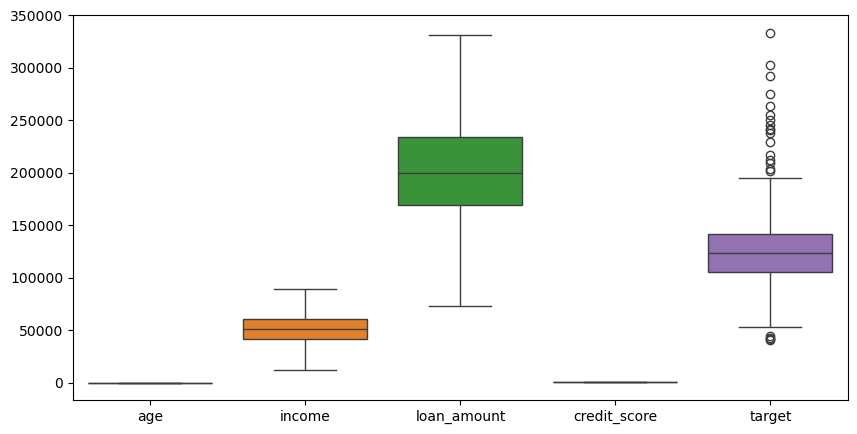

In [22]:
# box plot to check for outliers after capping
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

In [23]:
df.shape

(1000, 7)

In [25]:
# check the city column value counts
df['city'].value_counts()

city
Hyderabad    260
Chennai      259
Bangalore    256
Mumbai       225
Name: count, dtype: int64

In [26]:
# check the employee_type column value counts
df['employment_type'].value_counts()

employment_type
Self-Employed    356
Salaried         325
Unemployed       319
Name: count, dtype: int64

In [27]:
# handled the categorical variables by one hot encoding

cat = ['city', 'employment_type']
from sklearn.preprocessing import OneHotEncoder 

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(df[cat])

In [28]:
# encoded_data converted to dataframe
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(cat))
encoded_df

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
995,0.0,1.0,0.0,0.0,1.0,0.0,0.0
996,1.0,0.0,0.0,0.0,0.0,1.0,0.0
997,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [29]:
# concatenate the encoded dataframe with the original dataframe (excluding the categorical columns)
# drop the cat columns from the original dataframe
df.drop(columns=cat, inplace=True)

In [30]:
df.head()

,age,income,loan_amount,credit_score,target
0,56,25903.305196,286348.192562,789.476075,158793.631698
1,69,53051.954538,180018.190719,596.334039,115596.093965
2,46,38654.738821,211234.236288,611.531000,127231.057638
3,32,28666.194356,246629.541594,710.171152,145102.187078
4,60,40301.406736,129081.713353,622.900855,110623.128404


In [31]:
encoded_df.head()

,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [32]:
df =pd.concat([df, encoded_df], axis=1)
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,25903.305196,286348.192562,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,53051.954538,180018.190719,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,38654.738821,211234.236288,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,28666.194356,246629.541594,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,40301.406736,129081.713353,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [33]:
# find the skewness of input features
skewness = df.drop(columns=['target']).skew()
skewness

age                             -0.042322
income                           0.187505
loan_amount                      0.134521
credit_score                    -0.044087
city_Bangalore                   1.119865
city_Chennai                     1.101895
city_Hyderabad                   1.095950
city_Mumbai                      1.319085
employment_type_Salaried         0.748388
employment_type_Self-Employed    0.602389
employment_type_Unemployed       0.777843
dtype: float64

In [34]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()

print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)


Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [78]:
# check the normal , postive skewness and negative skewness features
normal_skewed_features = skewness[skewness == 0].index.tolist()
positive_skewed_features = skewness[skewness > 0].index.tolist()
negative_skewed_features = skewness[skewness < 0].index.tolist()
 
print("Normal skewed features: ", normal_skewed_features)
print("Positive skewed features: ", positive_skewed_features)
print("Negative skewed features: ", negative_skewed_features)
 

Normal skewed features:  []
Positive skewed features:  ['income', 'loan_amount', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed', 'city_Bangalore', 'city_Chennai', 'city_Hyderabad', 'city_Mumbai', 'employment_type_Salaried', 'employment_type_Self-Employed', 'employment_type_Unemployed']
Negative skewed features:  ['age', 'credit_score']


In [35]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['income', 'loan_amount']

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(df[num_cols])


In [36]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,789.476075,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,596.334039,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,611.531000,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,710.171152,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,622.900855,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [40]:
from sklearn.model_selection import train_test_split

# Features (input variables)
X = df.drop('target', axis=1)

# Target variable
y = df['target']

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (800, 11)
Testing data shape: (200, 11)


In [41]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Train the model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

# Predictions
y_pred = knn_model.predict(X_test)

# MSE
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 1150544257.404101


In [37]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

#make 2D array 

df['credit_score'] = scaler.fit_transform(df[['credit_score']])

In [38]:
df.head()

,age,income,loan_amount,credit_score,target,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
0,56,0.175537,0.825684,2.013602,158793.631698,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,69,0.526493,0.414927,-0.763656,115596.093965,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,46,0.340377,0.535516,-0.545133,127231.057638,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,32,0.211253,0.672249,0.873248,145102.187078,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,60,0.361664,0.218158,-0.381642,110623.128404,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [90]:
X_test

,age,income,loan_amount,credit_score,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,...,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed,city_Bangalore,city_Chennai,city_Hyderabad,city_Mumbai,employment_type_Salaried,employment_type_Self-Employed,employment_type_Unemployed
521,22,0.361594,0.432634,1.908087,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
737,49,0.903002,0.444404,0.734234,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
740,38,0.609935,0.635860,1.387546,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
660,56,0.457943,0.525599,-0.091718,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,59,0.713776,0.470946,0.224834,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,40,0.646138,0.597633,0.150209,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
332,58,0.687123,0.440251,1.852595,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
208,61,0.417046,0.605439,-1.015321,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
613,66,0.471389,0.477484,1.295877,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [91]:
y_train

29     120225.912489
535     61977.952624
695    124527.161195
557     76225.586596
836     97217.947007
           ...      
106    123432.668599
270     99654.806469
860    154444.353604
435    125160.818016
102    122326.980938
Name: target, Length: 800, dtype: float64

In [93]:
y_test

521    110471.776903
737    121748.553871
740    132938.442373
660    115222.901825
411    127576.987078
           ...      
408    141794.447930
332    132256.319908
208    134245.338603
613    128693.737524
78     126448.010486
Name: target, Length: 200, dtype: float64

In [94]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 25)
Testing data: (200, 25)


In [99]:
# model 1 : KNN Regression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

# Create KNN model
knn_regressor = KNeighborsRegressor(n_neighbors=5)

# Train the model
knn_regressor .fit(X_train, y_train)

# Predict on test data
y_pred = knn_regressor .predict(X_test)



In [100]:
from sklearn.metrics import mean_squared_error

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 1268271903.9990716


In [101]:
#Calculate accuracy (R2 score)
accuracy = r2_score(y_test, y_pred)

print("Model Accuracy (R2 Score):", accuracy)

Model Accuracy (R2 Score): -0.21563285240550756


In [102]:
# make the elbow plot to find the optimal value of k
mse_values=[]
k_values=range(1,21)
for k in k_values:
    knn_regressor=KNeighborsRegressor(n_neighbors=k)
    knn_regressor.fit(X_train,y_train)
    y_pred=knn_regressor.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_values.append(mse)
    

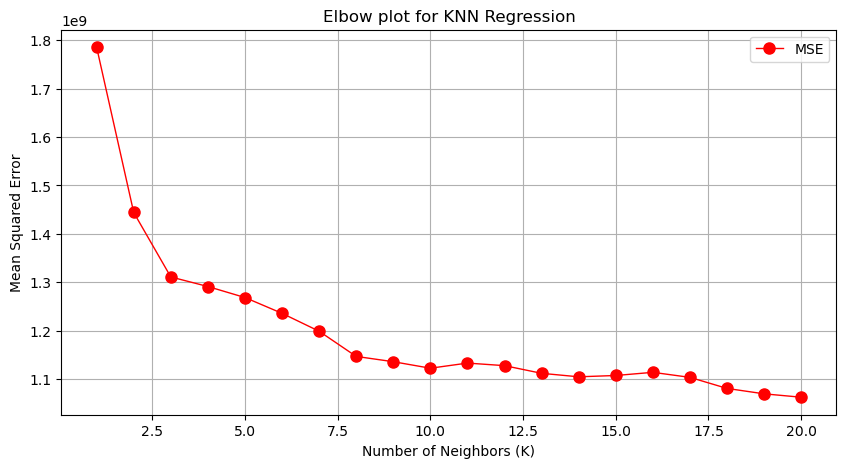

In [103]:
#plot the elbow plot
plt.figure(figsize=(10,5))
plt.plot(k_values,mse_values,marker='o',color='red',linewidth=True,markersize=8,label='MSE')
plt.title("Elbow plot for KNN Regression")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(True)

plt.show()


In [104]:
# Model 2: Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 204308498.00808188
R2 Score: 0.8041712337700486


In [105]:
# model 3: Decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create Decision Tree model
model = DecisionTreeRegressor(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Decision Tree Mean Squared Error:", mse)
print("Decision Tree R2 Score:", r2)

Decision Tree Mean Squared Error: 515234998.0229653
Decision Tree R2 Score: 0.5061495974712834


In [106]:
#model 4: Random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Create Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("Random Forest Mean Squared Error:", mse)
print("Random Forest R2 Score:", r2)

Random Forest Mean Squared Error: 206808381.89435494
Random Forest R2 Score: 0.8017751064334969
